# Домашня робота 2 — K-Means квантизація та QAT для VGG11 на CIFAR-10

**Курс:** Efficient ML, SET University

Беремо навчену в ДЗ1 щільну VGG11 (90.71% на тесті) і стискаємо її
**квантизацією зі спільними вагами** (weight sharing, стиль Deep Compression). Для
кожного шару кластеризуємо ваги в K = 2^bits центроїдів: замість мільйонів різних
чисел лишається маленький словник (codebook) і по одному короткому індексу на вагу.
2 біти — це лише 4 різні значення ваги на шар, 4 біти — 16.

Далі — **QAT за діаграмою зі слайда 36**: індекси кластерів заморожені, а самі
центроїди до-навчаємо. Робимо звичайний forward/backward, **пулимо градієнти за
індексом кластера** (усереднюючи в межах кластера) і крокуємо центроїди. Це те, що
дозволяє навіть 2-бітній моделі відігратися.

**Методологія.** Стартова fp32-модель узята з ДЗ1 (не перенавчаємо — спільна
відправна точка для всіх). Тест міряємо рівно один раз на кожну фінальну модель;
усі проміжні числа (PTQ, криві QAT, аналіз чутливості) — на валідації.
Mixed-precision порівнюємо з uniform **за Парето на однаковому розмірі**: точка
mixed має лежати вище лінії uniform-квантизацій того самого розміру.

### Підсумок (тест — раз на модель)

| Модель | Біт/вагу | Стиснення | Розмір, МБ | val | Точність (тест) |
|---|---|---|---|---|---|
| Baseline fp32 (з ДЗ1) | 32 | 1× | 37.98 | 91.56% | **90.71%** |
| K-Means 2-bit (QAT) | 2 | 15.8× | 2.41 | 40.30% | **88.20%** |
| K-Means 3-bit (QAT) | 3 | 10.6× | 3.59 | 84.98% | **89.72%** |
| K-Means 4-bit (QAT) | 4 | 7.9× | 4.78 | 90.82% | **90.34%** |
| Bonus: mixed ~2.48-bit (3 seeds) | 2.48 | — | 2.98 | — | 90.52±0.05% |
| **Прунінг+mixed ~2.48-bit (бонус)** | 2.48 | **19.2×** | 1.97 | — | **90.46±0.06%** |
| Прунінг+квант 4-bit (Deep Compression) | 4 | 17.5× | 2.17 | — | 90.47% |

Стовпчик **val**: для baseline — валідація fp32; для квант-рядків — валідація після
PTQ (до-навчання). Bonus-рядки — середнє ± std за 3 seed.

> **Про розмір.** Колонка «Розмір» — це **теоретичний packed-size** серіалізованого
> формату: codebook (K×fp32) + bit-packed індекси (log₂K на вагу), для
> прунінг-рядків ще + бітова маска позицій. Це **не** розмір поточного PyTorch
> checkpoint/RAM: у нас індекси лежать як `int64`, а ваги під час forward
> матеріалізуються назад у fp32. Тобто 4.78 МБ для 4-біт — коректна
> оцінка запакованого файлу, а не фактичний обсяг пам'яті поточної реалізації.

4-бітна квантизація майже без втрат (7.9× стиснення).
Найкраще співвідношення точність/розмір — **прунінг + mixed-precision квантизація**:
90.46±0.06% при 19.2×. Mixed-precision
на обох бюджетах лежить вище Парето-лінії uniform (на щільній моделі навіть перевищує
uniform-3-bit за менший розмір) — деталі й похибки за 3 seed нижче.

## 1. Підготовка

In [1]:
import json, inspect
import torch
import matplotlib.pyplot as plt

from src.utils import set_seed, get_device
from src.data import build_loaders, CIFAR_MEAN, CIFAR_STD
from src.model import build_vgg11_cifar, count_parameters
from src import kmeans_quant, qat, mixed, plots

RESULTS = "results"
set_seed(42)
device = get_device()
print("device:", device, "| torch:", torch.__version__)

device: cuda | torch: 2.11.0+cu130


## 2. Дані та модель

CIFAR-10, той самий поділ, що й у ДЗ1: 45 000 train / 5 000 val / 10 000 test.
Валідація — для всіх проміжних рішень, тест — на самий кінець. Стартова модель —
щільна VGG11 з ДЗ1 (fp32, 90.71% на тесті, 37.98 МБ).

In [2]:
train_loader, val_loader, test_loader = build_loaders("./data", batch_size=256)
print(f"train={len(train_loader.dataset)}  val={len(val_loader.dataset)}  test={len(test_loader.dataset)}")

base = build_vgg11_cifar().to(device)
base.load_state_dict(torch.load("../hw1/results/baseline.pt", map_location=device))
print(f"Параметрів: {count_parameters(base)/1e6:.2f}M")

/home/deploy/efficientml/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train=45000  val=5000  test=10000


Параметрів: 9.49M


## 3. Як працює K-Means квантизація

Для кожного згорткового/повнозв'язного шару беремо всі його ваги і кластеризуємо
їх у K = 2^bits центроїдів одновимірним k-means. Кожна вага замінюється значенням
свого центроїда. Ініціалізацію центроїдів беремо лінійною (рівномірно від min до
max ваги) — так радить Deep Compression: великі за модулем ваги рідкісні, але
важливі, а щільнісна ініціалізація їх недо-представляє.

Зберігаємо два об'єкти на шар: **codebook** (K чисел fp32) і **карту індексів**
(по log2(K) біт на вагу). Звідси й стиснення.

In [3]:
print(inspect.getsource(kmeans_quant.kmeans_1d))

@torch.no_grad()
def kmeans_1d(values: torch.Tensor, k: int, iters: int = 30,
              nonzero_only: bool = False):
    """Cluster a flat tensor of weights into k centroids (Lloyd's algorithm).

    Returns (centroids[k], labels[N]) where labels index into centroids for every
    input value. When `nonzero_only` is set, exactly-zero weights (e.g. pruned
    ones) are excluded from clustering and reported with label -1 so the caller
    can keep them pinned at zero.
    """
    flat = values.flatten()
    if nonzero_only:
        active = flat != 0
    else:
        active = torch.ones_like(flat, dtype=torch.bool)

    labels = flat.new_full(flat.shape, -1, dtype=torch.long)
    pts = flat[active]
    if pts.numel() == 0:                       # whole layer pruned away
        return flat.new_zeros(k), labels.view_as(values)

    k = min(k, pts.numel())                    # can't have more clusters than points
    centroids = _linear_init(pts, k).clone()

    for _ in range(iters):

Подивимось на розподіл ваг одного шару і куди стали центроїди після кластеризації
(3-бітний приклад, K=8). Центроїди сідають щільніше там, де ваг більше, але лінійна
ініціалізація не забуває про хвости.

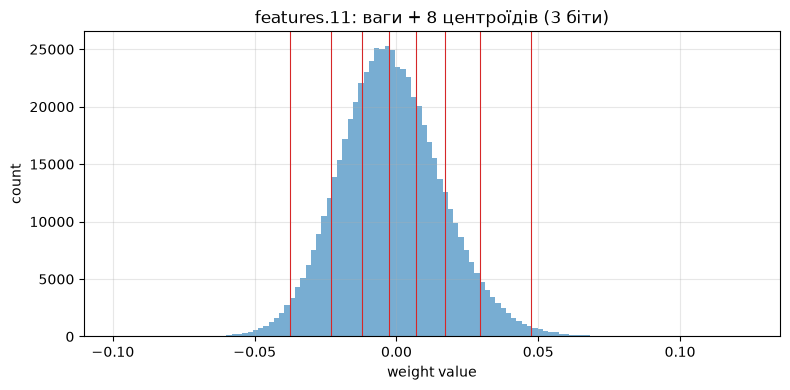

унікальних значень ваги після квантизації: 8


In [4]:
layer_name = [n for n, m in kmeans_quant.quantizable_layers(base)
              if isinstance(m, torch.nn.Conv2d)][3]
w = dict(base.named_modules())[layer_name].weight.data
cents, labels = kmeans_quant.kmeans_1d(w, k=8, iters=30)
plots.plot_weight_hist(w.flatten().cpu().numpy(), cents.cpu().numpy(),
                       f"{layer_name}: ваги + 8 центроїдів (3 біти)")
plt.show()
print("унікальних значень ваги після квантизації:", len(cents))

### QAT — до-навчання центроїдів (слайд 36)

Ключова частина. Ваги шару лишаються leaf-параметром; після `loss.backward()`
кожна вага має свій градієнт. Ми **пулимо** ці градієнти за індексом кластера і
крокуємо центроїди, а ваги матеріалізуємо назад як `codebook[index]`. Індекси
заморожені — рухаються лише K значень словника на шар.

Точніше про те, що саме рухається: **квантизовані ваги (Conv/Linear) оновлюються
ЛИШЕ через свої центроїди** — окремі ваги ніколи не крокуються напряму. Дрібні
не-квантизовані параметри — bias і affine-параметри BatchNorm (γ, β) — лишаються
fp32; за замовчуванням (`adapt_extras=True`) ми даємо їм теж адаптуватися, бо це
відчутно допомагає (ablation нижче: +6.2 п.п. на 2-бітах). З
`adapt_extras=False` рухаються **тільки центроїди**.

**Формула пулінгу.** Для центроїда c, який спільний для ваг кластера S_c:

$$g_c^{\text{sum}} = \sum_{i \in S_c} \frac{\partial L}{\partial W_i}
\qquad\qquad
g_c^{\text{mean}} = \frac{1}{|S_c|} \sum_{i \in S_c} \frac{\partial L}{\partial W_i}$$

**sum** — буквальна реалізація слайда (це точний градієнт репараметризації
W_i = C_c). **mean** — нормалізований варіант (середній градієнт кластера), який
ми й використали. Різниця важлива, бо розміри кластерів різняться на порядки (у
2-бітному conv-шарі ~500k ваг на 4 кластери, у класифікаторі — ~1k): із **sum**
крок центроїда пропорційний розміру кластера, тож під звичайним SGD великі кластери
переганяють і навчання **розходиться** (ablation нижче: sum під SGD падає до
10.00%). Під **Adam**, який нормалізує крок кожного
центроїда за його ж статистикою, sum і mean майже збігаються
(87.84% проти 87.98%) —
але mean лишається коректним незалежно від оптимізатора, тому ми беремо його.

In [5]:
print(inspect.getsource(kmeans_quant.KMeansQuantizer.pool_gradients))

    @torch.no_grad()
    def pool_gradients(self, model, mode: str = "mean"):
        """Slide-36 step: pool per-weight grads into per-centroid grads.

        For a centroid c shared by the weights in cluster S_c:

            sum : g_c = Σ_{i in S_c} dL/dW_i          (the literal diagram)
            mean: g_c = (1/|S_c|) Σ_{i in S_c} dL/dW_i (what we use)

        The `sum` form is the exact gradient of the reparametrisation W_i = C_c, so
        it is "correct". But cluster sizes span orders of magnitude (a 2-bit conv
        layer packs ~500k weights into 4 clusters, the classifier only ~1k), so
        with `sum` a single learning rate makes each centroid's step scale with its
        cluster size -- big clusters overshoot, small ones stall (plain SGD diverges
        within a couple of epochs; see the ablation). `mean` normalises that out --
        same descent direction, well-conditioned step regardless of cluster size --
        so it is robust across optimisers. Pinned (prun

## 4. Свіп по бітності: PTQ проти QAT

Для кожної бітності [2, 3, 4] робимо дві точки:
- **PTQ** — лише кластеризація, без до-навчання (скільки коштує сама квантизація);
- **QAT** — далі до-навчаємо центроїди градієнтним пулінгом.

Різниця між ними і є цінністю QAT. На агресивних 2 бітах вона найбільша.

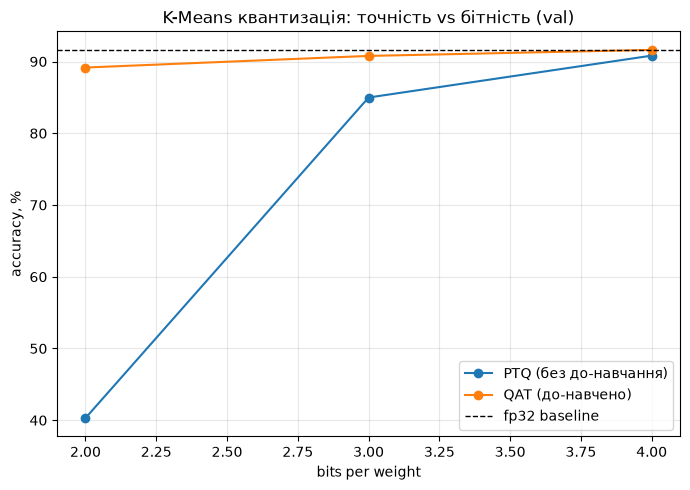

TEST (раз на модель):
  2bit: PTQ val 40.30%  ->  QAT val 89.16%  TEST 88.20%   2.41MB (15.8x)
  3bit: PTQ val 84.98%  ->  QAT val 90.78%  TEST 89.72%   3.59MB (10.6x)
  4bit: PTQ val 90.82%  ->  QAT val 91.62%  TEST 90.34%   4.78MB (7.9x)


In [6]:
km = json.load(open(f"{RESULTS}/kmeans.json"))
bit_keys = sorted((k for k in km if k.endswith("bit")), key=lambda k: int(k[:-3]))
ptq = [(int(k[:-3]), km[k]["ptq_val"]) for k in bit_keys]
qat_v = [(int(k[:-3]), km[k]["qat_val"]) for k in bit_keys]
plots.plot_bits_vs_acc({"PTQ (без до-навчання)": ptq, "QAT (до-навчено)": qat_v},
                       baseline_acc=km["fp32"]["val"],
                       title="K-Means квантизація: точність vs бітність (val)")
plt.show()
print("TEST (раз на модель):")
for k in bit_keys:
    r = km[k]
    print(f"  {k}: PTQ val {r['ptq_val']*100:5.2f}%  ->  QAT val {r['qat_val']*100:5.2f}%  "
          f"TEST {r['qat_test']*100:5.2f}%   {r['size_MB']:.2f}MB ({r['compression_x']:.1f}x)")

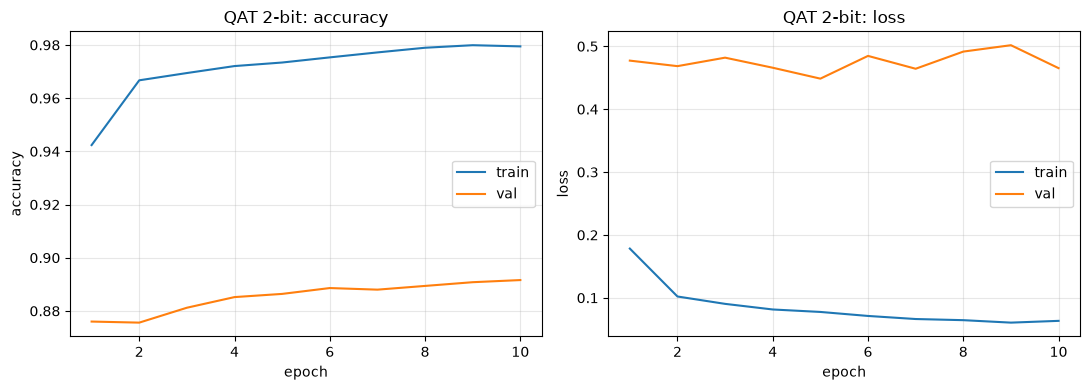

In [7]:
r = km["2bit"]                     # QAT recovery curve at the most aggressive bit-width
plots.plot_history(r["history"], "QAT 2-bit")
plt.show()

**Що видно.** Post-training на 3–4 бітах падає помірно, а на 2 бітах (лише 4
значення на шар) модель майже ламається — саме там до-навчання центроїдів дає
найбільше (40.30% → 89.16%
на val). Компроміс «розмір↔точність»: 4-бітна модель стискає у
7.9× майже без втрат
(90.34% на тесті), а 2-бітна — у
15.8×, але коштує точності.

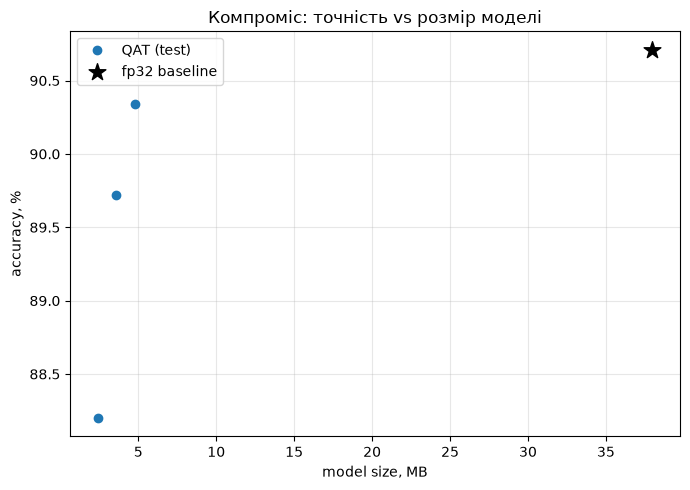

In [8]:
plots.plot_size_vs_acc(
    {"QAT (test)": [(km[k]["size_MB"], km[k]["qat_test"]) for k in bit_keys]},
    baseline=(km["fp32"]["size_MB"], km["fp32"]["test"]),
    title="Компроміс: точність vs розмір моделі")
plt.show()

## 5. Бонус, частина 1 — mixed-precision за аналізом чутливості

Не всі шари однаково крихкі. Спочатку робимо **аналіз чутливості до бітності**:
квантизуємо по черзі лише один шар (решта fp32) на 2/3/4 біти і дивимось на
валідацію. Шари, де точність провалюється на 2 бітах, — чутливі, їм треба більше
біт; стійким вистачить менше.

Далі жадібно розподіляємо біти під **фіксований середній бюджет** (~2.48
біт). Важливо: беремо бюджет у «болючому» діапазоні 2–3 біт, де uniform уже втрачає
точність — саме там розумний розподіл має шанс допомогти (на 4 бітах усе й так майже
без втрат, там вигравати нема на чому).

**Порівняння за Парето.** Uniform існує лише в цілих бітах, тож будуємо Парето-лінію
uniform-2 і uniform-3 і дивимось, чи точка mixed лежить **вище** цієї лінії на
своєму розмірі. Щоб зняти питання шуму, всі точки — **середнє ± std за 3 seed**
(між запусками точність гуляє на кілька десятих через перемішування даних і dropout).

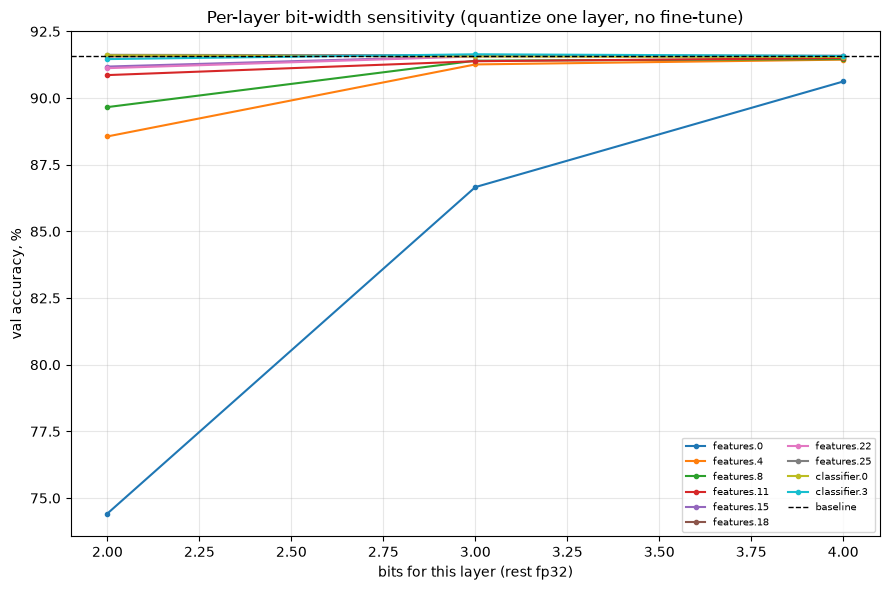

Розподіл біт (mixed):
  features.0                  : 4 біт
  features.4                  : 4 біт
  features.8                  : 3 біт
  features.11                 : 3 біт
  features.15                 : 3 біт
  features.18                 : 2 біт
  features.22                 : 3 біт
  features.25                 : 2 біт
  classifier.0                : 2 біт
  classifier.3                : 4 біт
середнє = 2.483 біт


In [9]:
mx = json.load(open(f"{RESULTS}/mixed.json"))
plots.plot_bit_sensitivity(mx["bit_sensitivity"], mx["fp32"]["val"])
plt.show()
print("Розподіл біт (mixed):")
for n, b in mx["mixed_bits"].items():
    print(f"  {n:28s}: {b} біт")
print(f"середнє = {mx['mixed_avg_bits']:.3f} біт")

In [10]:
sd = json.load(open(f"{RESULTS}/seeds.json"))
u, m = sd["dense"]["uniform"], sd["dense"]["mixed"]
print(f"Парето-порівняння, {len(sd['seeds'])} seed (mean±std, тест):")
for b in sorted(u, key=int):
    print(f"  uniform {b}-bit : {u[b]['mean']*100:.2f}±{u[b]['std']*100:.2f}%  {u[b]['size_MB']:.2f}MB")
print(f"  mixed {m['avg_bits']:.2f}-bit: {m['mean']*100:.2f}±{m['std']*100:.2f}%  {m['size_MB']:.2f}MB")
print(f"  лінія uniform на розмірі mixed = {m['pareto_bar']*100:.2f}%")
print(f"  --> mixed {'вище' if m['beats'] else 'нижче'} лінії на "
      f"{(m['mean']-m['pareto_bar'])*100:+.2f} п.п.")

Парето-порівняння, 3 seed (mean±std, тест):
  uniform 2-bit : 88.14±0.13%  2.41MB
  uniform 3-bit : 89.79±0.11%  3.59MB
  mixed 2.48-bit: 90.52±0.05%  2.98MB
  лінія uniform на розмірі mixed = 88.94%
  --> mixed вище лінії на +1.58 п.п.


**Висновок частини 1.** На бюджеті ~2.48 біт mixed-precision дає
90.52±0.05% на тесті (3 seed) — це +1.58 п.п.
над Парето-лінією uniform того самого розміру. Причому тут mixed навіть перевищує
точність uniform-3-bit (89.79±0.11%)
**за менший розмір** (2.98 проти 3.59 МБ) —
розрив (+0.73 п.п.) помітно більший за
розкид між сідами (std ≈ 0.05), тож це не шум. Логіка: перші
згортки й класифікатор чутливі — їм віддали 4 біти; товсті стійкі середні шари
пережили 2 біти, і в середньому це дешевше й точніше за рівні 3 біти.

(Ремарка: на бюджеті 3–4 біт mixed і uniform були б у межах шуму — там втрачати вже
майже нема на чому, тож розподіл бітів не вирішує. Тому бюджет обрано «болючий».)

## 6. Бонус, частина 2 — покращуємо результат прунінгу (Deep Compression)

Це прямо те, чого просить умова бонусу: **покращити результат ітеративного прунінгу
за допомогою mixed-precision квантизації**. Беремо 80%-розріджену модель з ДЗ1
(90.74% на тесті) і квантизуємо **лише ненульові** ваги
(нулі лишаються нулями). Порівнюємо два способи квантизації цієї самої pruned-моделі:
uniform-precision і mixed-precision — знову за Парето на однаковому розмірі, у
форматі sparse+quantized (codebook + індекс на ненульову вагу + бітова маска позицій).

In [11]:
sd = json.load(open(f"{RESULTS}/seeds.json"))
pu, pmx = sd["prune"]["uniform"], sd["prune"]["mixed"]
print(f"прунінг (80%): лише прунінг TEST {sd['prune']['pruned_only_test']*100:.2f}%")
print(f"прунінг + квантизація ({len(sd['seeds'])} seed, mean±std, sparse+quant розмір):")
for b in sorted(pu, key=int):
    print(f"  + uniform {b}-bit : {pu[b]['mean']*100:.2f}±{pu[b]['std']*100:.2f}%  {pu[b]['size_MB']:.2f}MB")
print(f"  + mixed {pmx['avg_bits']:.2f}-bit: {pmx['mean']*100:.2f}±{pmx['std']*100:.2f}%  {pmx['size_MB']:.2f}MB "
      f"--> {'вище' if pmx['beats'] else 'нижче'} лінії на {(pmx['mean']-pmx['pareto_bar'])*100:+.2f} п.п.")
mxj = json.load(open(f"{RESULTS}/mixed.json")); phi = mxj["prune_quant_headline"]
print(f"  + uniform {phi['bits']}-bit (headline, 1 seed): TEST {phi['qat_test']*100:.2f}%  "
      f"{phi['sparse_MB']:.2f}MB  ({phi['compression_x']:.1f}x vs fp32)")

прунінг (80%): лише прунінг TEST 90.74%
прунінг + квантизація (3 seed, mean±std, sparse+quant розмір):
  + uniform 2-bit : 88.25±0.26%  1.70MB
  + uniform 3-bit : 90.14±0.06%  1.93MB
  + mixed 2.48-bit: 90.46±0.06%  1.97MB --> вище лінії на +0.31 п.п.
  + uniform 4-bit (headline, 1 seed): TEST 90.47%  2.17MB  (17.5x vs fp32)


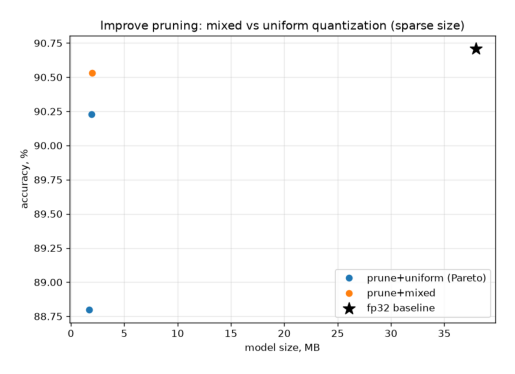

In [12]:
plt.figure()
img = plt.imread(f"{RESULTS}/prune_mixed_pareto.png"); plt.imshow(img); plt.axis("off"); plt.show()

**Висновок частини 2.** Прунінг і квантизація — ортогональні осі стиснення й
складаються: разом виходить до 17.5× при 90.47%
(≈ baseline). На pruned-моделі mixed-precision дає +0.31 п.п. над Парето-лінією
uniform (3 seed): 90.46±0.06% проти
90.14±0.06% для uniform-3-bit.
Виграш скромніший, ніж на щільній моделі, але **стабільний між сідами** (std ≈
0.06, тобто не шум): розумний розподіл бітів покращує вже стиснуту
прунінгом модель. Практичний рецепт для edge-девайсів (Raspberry Pi у фінальному проекті).

## 7. Ablation: дві перевірки рецепта QAT

**(1) Пулінг градієнтів — sum vs mean, під SGD і під Adam** (2-бітна модель):

| оптимізатор | mean (наш) | sum (буквальний слайд) |
|---|---|---|
| SGD | 88.40% (стабільно) | **10.00% — РОЗХОДИТЬСЯ** |
| Adam (наш) | 87.98% | 87.84% |

Під **SGD** sum розвалює навчання (крок центроїда ∝ розміру кластера — cluster-size
scaling), а mean стабільний. Під **Adam** sum і mean майже збігаються, бо Adam і так
нормалізує крок кожного центроїда. Математично точний градієнт репараметризації
W_i = C_c — це саме **sum**; **mean** = той самий напрямок, нормований на розмір
кластера (per-cluster preconditioning). Тож mean — не «правильніший», а **стабільний
практичний варіант**: він не залежить від того, чи оптимізатор сам нормалізує крок.

**(2) Що саме навчається — тільки центроїди vs + bias/BN:**

| бітність | тільки центроїди | + bias/BN (наш дефолт) | внесок extras |
|---|---|---|---|
| 2-bit | 81.98% | 88.14% | **+6.16 п.п.** |
| 3-bit | 89.17% | 90.26% | +1.09 п.п. |

Квантизовані ваги завжди рухаються лише через центроїди; питання лише в тому, чи
дати адаптуватися дрібним fp32-параметрам (bias, BN γ/β). На 2 бітах це критично
(+6.16 п.п.), на 3 — менше, але стабільно позитивно. Тому дефолт — `adapt_extras=True`.

## 8. Як ми це робили: підходи та спроби

Коротко про шлях, а не лише про фінал.

**Стартова точка.** Не перенавчали модель — узяли готову щільну VGG11 з ДЗ1 і весь
код даних/навчання звідти, а зверху дописали лише квантизацію. Так HW2 стоїть рівно
на тому самому baseline.

**QAT — де довелося повозитися.** Донавчання центроїдів попервах розвалювало
модель, і ми пройшли кілька ітерацій, поки знайшли причини:
- *сума* градієнтів у кластері (як на діаграмі) нестабільна — розміри кластерів
  різняться на порядки, тож один learning rate розриває великі кластери. Перейшли
  на **усереднення** в межах кластера;
- валідація сильно відставала від train → додали **рекалібрацію BatchNorm** під
  зсунуті ваги перед кожною валідацією;
- модель розходилася через кілька епох → виявилось, що градієнти conv-ваг
  **накопичувалися між батчами** (ваги лежать поза оптимізатором) — полагодили
  обнуленням щобатч;
- SGD+momentum на «зв'язаній» поверхні центроїдів переганяв → замінили на **Adam**.
Після цих чотирьох правок QAT став стабільним і монотонним.

**Бонус — теж не з першого разу.** Спершу пробували mixed-precision на бюджеті 3
біти і **не виграли** — на такій бітності uniform уже майже без втрат, вигравати
нема на чому. Звідси урок: mixed має сенс лише там, де uniform втрачає точність.
Перейшли на «болючі» ~2.5 біт — і воно спрацювало; той самий розподіл застосували
до розрідженої моделі з ДЗ1, що й дало найкращу точку.

**Результати** — у підсумковій таблиці на початку: 4-біт майже без втрат (7.9×),
2-біт рятується QAT-ом (40.30% → 88.20%),
mixed тримається над Парето-лінією uniform, а prune+mixed — 90.46±0.06%
при 19.2× (найкраще співвідношення точність/розмір).

## 9. Звіт: висновки і рефлексія

**Що спрацювало добре.** K-Means weight sharing стискає VGG11 у кілька разів майже
без втрати точності: 4-бітна модель — 90.34%
на тесті проти 90.71% fp32, при 7.9×
стисненні. QAT-пулінг градієнтів за слайдом 36 працює як задумано: на 2 бітах він
піднімає валідацію з 40.30% (PTQ) до
89.16%. Бонус: mixed-precision (3 seed)
лежить +1.58 п.п. над Парето-лінією uniform — на щільній моделі навіть
**перевищує uniform-3-bit** (90.52±0.05% проти
89.79±0.11%, +0.73 п.п.)
**за менший розмір**; на pruned-моделі виграш скромніший (+0.31 п.п.), але
стабільний між сідами (std ≈ 0.06, не шум). Разом
прунінг+квантизація стискає до 19.2× при
90.46±0.06% (≈ baseline).

**Що вийшло не так, як очікувалось.** По-перше, 2-бітна квантизація без до-навчання
майже руйнує модель (40.30% на val) — 4 значення на
шар замало. По-друге (і це головний методологічний урок): **mixed-precision виграє
лише там, де uniform уже втрачає точність** — у діапазоні 2–3 біт. На 3–4 бітах
uniform практично без втрат, тож на нашому першому бюджеті (3 біти) mixed і uniform
були в межах шуму; довелося свідомо обрати «болючий» бюджет ~2.5 біт, щоб розподіл
почав щось вирішувати.

**Чому результати можуть бути не ідеальними.** (1) Заявлений розмір — це
**теоретичний packed-size** (codebook + bit-packed індекси), а не розмір поточного
checkpoint: у нас індекси лежать як int64, а ваги матеріалізуються у fp32. Тобто
економія пам'яті — на папері, а не в поточній реалізації. (2) І це *розмір*, а не
швидкість: без спец-ядра weight sharing не прискорює inference. (3) BatchNorm/bias
під час QAT адаптуються (ablation: +6.2 п.п. на 2 бітах), тож
формально частина мережі не квантизована. (4) 1-D k-means по кожному шару окремо не
враховує взаємодію між шарами; розподіл бітів жадібний.

**Як покращити.** Комбінувати з дистиляцією (вчити квантизовану модель під
fp32-вчителя); квантизувати ще й активації (тоді буде реальне прискорення на
INT-арифметиці); тонший, не жадібний розподіл бітності; Хаффман-кодування індексів
(третій крок Deep Compression); для Raspberry Pi — експорт у формат із реальною
INT8-підтримкою (ONNX/TFLite).

## 10. Відтворення

```bash
python run_kmeans.py   --baseline ../hw1/results/baseline.pt --data-dir ./data --out results
python run_mixed.py    --baseline ../hw1/results/baseline.pt \
    --pruned ../hw1/results/iterative_final.pt --data-dir ./data --out results
python run_ablation.py --baseline ../hw1/results/baseline.pt --data-dir ./data --out results
python run_seeds.py    --seeds 0 1 2 --baseline ../hw1/results/baseline.pt \
    --pruned ../hw1/results/iterative_final.pt --data-dir ./data --out results
python build_notebook.py results
python -m pytest tests/          # scatter_add pooling + zeros-preserved
```

Код у `src/`: `kmeans_quant.py` (кластеризація + пулінг градієнтів), `qat.py`
(до-навчання центроїдів + BN-рекалібрація), `mixed.py` (чутливість до бітності +
розподіл), `plots.py`; `data/model/engine/prune/sensitivity/utils` — реюз із ДЗ1.
Версії пакетів — у `requirements.txt`.